<a href="https://colab.research.google.com/github/mithun30052001/iit-aiml-assignments/blob/main/the-eda-checklist/EDA_checklist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [9]:
#Task 1 — Inspect & Handle Missing Values

#Print the shape of the DataFrame
print("Shape of DataFrame:", df.shape)

Shape of DataFrame: (200, 6)


In [10]:
#Display the data types of all columns.
print("Data Types:\n", df.dtypes)

Data Types:
 order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object


In [12]:
#Count the number of missing values in each column.
print("Missing Values Count:\n", df.isnull().sum())

Missing Values Count:
 order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64


In [14]:
#Calculate the percentage of missing values for each column, rounded to 2 decimal places.
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentage (%):\n", missing_percentage.round(2))


Missing Percentage (%):
 order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


In [17]:
#Task 2 — Summarize & Visualize
#Use df.describe() to generate a summary of all numerical columns.
print(f"Summary of all numerical columns:\n {df.describe()}")

Summary of all numerical columns:
           order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000


In [18]:
'''The order_value column has a very high maximum compared to its 75th percentile, indicating the presence of outliers.
The delivery_days column has a relatively small range, but any unusually high values may stand out as potential outliers.'''

'The order_value column has a very high maximum compared to its 75th percentile, indicating the presence of outliers.\nThe delivery_days column has a relatively small range, but any unusually high values may stand out as potential outliers.'

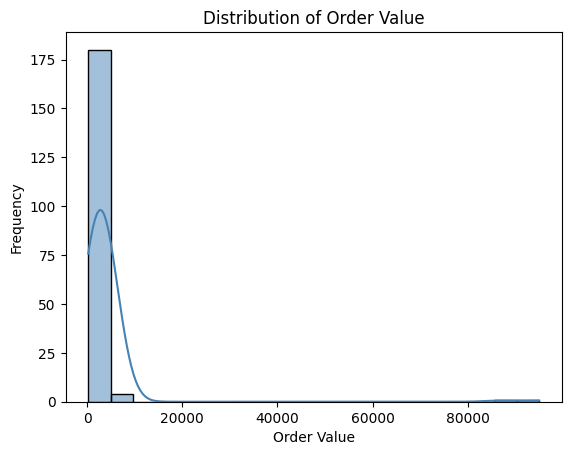

In [24]:
#Plot a histogram for the order_value column to visualize its distribution.
import seaborn as sns
import matplotlib.pyplot as plt


sns.histplot(data = df, x='order_value', bins=20, kde=True, color='steelblue' )
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

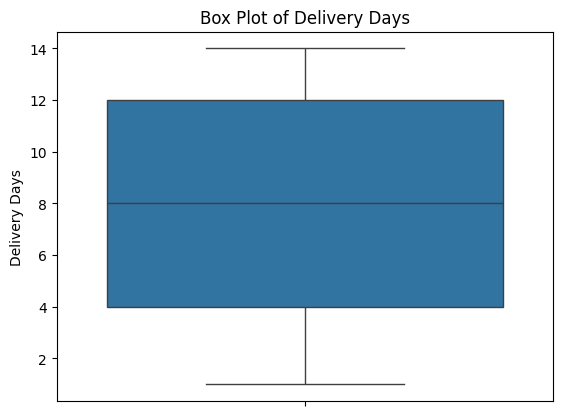

In [26]:
#Plot a box plot for the delivery_days column to inspect for outliers.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, y='delivery_days')

plt.title("Box Plot of Delivery Days")
plt.ylabel("Delivery Days")

plt.show()

In [28]:
#Task 3 — Correlation Analysis
#Compute the correlation matrix for all numerical columns using df.corr()

corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


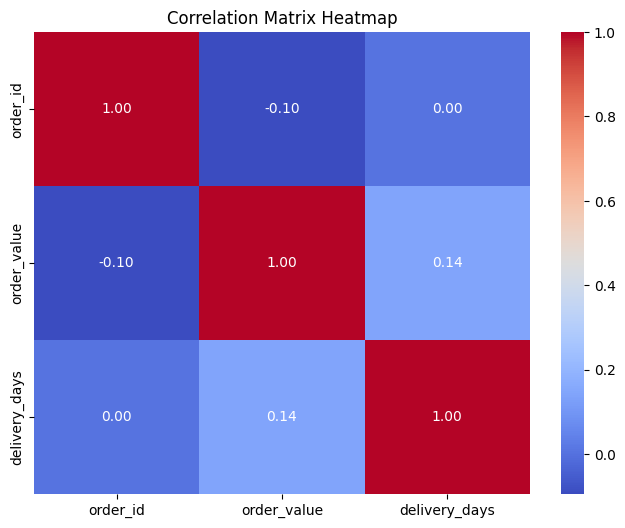

In [30]:
#Plot a heatmap of the correlation matrix with annotation values visible inside each cell.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix Heatmap")
plt.show()


In [ ]:
'''There is a slight positive correlation (≈ 0.14) between order_value and delivery_days, indicating that higher-value orders may take slightly longer to deliver
There is a slight negative correlation (−0.10) between order_id and order_value, indicating a very weak inverse relationship'''